In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

DATA_PATH = Path(
    os.getenv("DATA_PATH", "yellow_tripdata_2026-05_clean.parquet")
).expanduser()

OUTPUT_DIR = Path(
    os.getenv("OUTPUT_DIR", "outputs")
).expanduser()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"데이터 파일을 찾을 수 없습니다: {DATA_PATH}\n"
        "Colab에서는 파일을 /content에 업로드하고, "
        "로컬에서는 .env의 DATA_PATH를 확인해주세요."
    )

print(f"데이터: {DATA_PATH.resolve()}")
print(f"결과 저장: {OUTPUT_DIR.resolve()}")

데이터: /content/yellow_tripdata_2026-05_clean.parquet
결과 저장: /content/outputs


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

## 시각화(Visualization) — 통계 분석 전 데이터 개요

가설별 통계 검정(H1, H2, ...)에 들어가기 전에, 전체 데이터가 어떤 모양인지 먼저 눈으로 확인한다. 통계 검정을 돌리기 전에 데이터를 보지 않으면 결과 해석에서 실수하기 쉽다.

- **정적 시각화 (Seaborn)**: 운행 거리(`trip_distance`) 분포 — 대부분의 운행이 얼마나 짧은지, 공항 운행이 분포를 어떻게 다르게 만드는지 확인한다.
- **동적 시각화 (Plotly)**: 시간대별 운행 수요 패턴 — 평일과 주말의 하루 중 수요 곡선이 어떻게 다른지 hover로 정확한 수치를 확인하며 탐색한다.

In [ ]:
import seaborn as sns
import plotly.express as px

# 이후 두 차트가 함께 쓰는 데이터. pickup_dt는 평일/주말 날짜 수를 세기 위해 필요하다.
eda_columns = ["pickup_dt", "trip_distance", "is_airport_trip", "pickup_hour", "is_weekend"]
eda_trips = pd.read_parquet(DATA_PATH, columns=eda_columns)
eda_trips["pickup_date"] = eda_trips["pickup_dt"].dt.date
print(f"시각화 대상: {len(eda_trips):,}건")

EDA_BLUE, EDA_ORANGE, EDA_GRAY = "#2a78d6", "#eb6834", "#898781"


시각화 대상: 3,881,420건


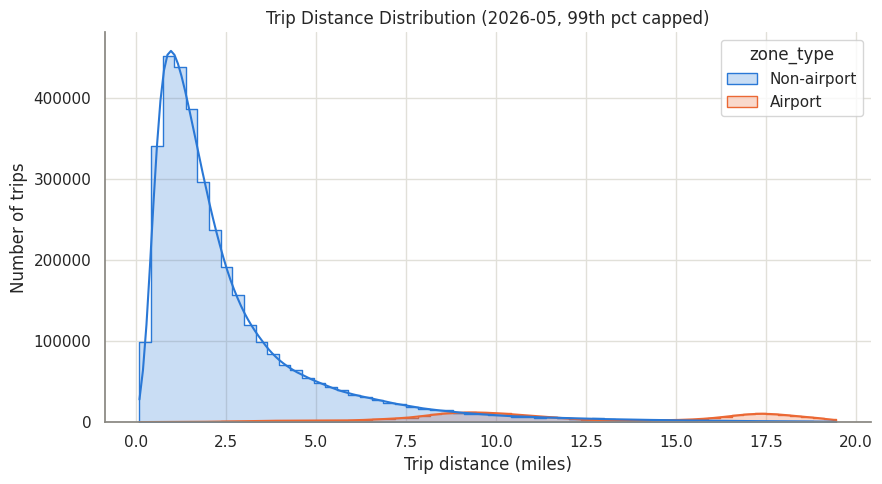

In [ ]:
# 정적 시각화(Seaborn): 운행 거리 분포. 상위 1%는 공항 왕복 등 극단적으로 긴 거리라
# 히스토그램 전체 형태를 눌러버리므로 99분위수로 절사해서 표시한다.
eda_dist_cap = eda_trips["trip_distance"].quantile(0.99)
eda_dist_plot = eda_trips.loc[eda_trips["trip_distance"] <= eda_dist_cap].copy()
eda_dist_plot["zone_type"] = eda_dist_plot["is_airport_trip"].map({True: "Airport", False: "Non-airport"})

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": EDA_GRAY, "grid.color": "#e1e0d9"})
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=eda_dist_plot, x="trip_distance", hue="zone_type", hue_order=["Non-airport", "Airport"],
    palette=[EDA_BLUE, EDA_ORANGE], bins=60, kde=True, element="step", ax=ax,
)
ax.set_title("Trip Distance Distribution (2026-05, 99th pct capped)")
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Number of trips")
for eda_spine in ["top", "right"]:
    ax.spines[eda_spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_trip_distance_hist.png", dpi=150)
plt.show()


In [ ]:
# 동적 시각화(Plotly): 평일 vs 주말 시간대별 운행 수요 패턴.
# 2026년 5월은 평일 21일, 주말 10일로 날짜 수가 다르다. 단순 합계로 비교하면
# 날짜 수가 많은 평일이 항상 높게 나오는 착시가 생기므로, 날짜 수로 나눠
# "하루 평균 운행 건수"로 정규화해야 공정하게 비교할 수 있다.
eda_n_days = eda_trips.groupby("is_weekend")["pickup_date"].nunique()
eda_hourly = eda_trips.groupby(["pickup_hour", "is_weekend"]).size().reset_index(name="trips")
eda_hourly["group"] = eda_hourly["is_weekend"].map({True: "Weekend", False: "Weekday"})
eda_hourly["n_days"] = eda_hourly["is_weekend"].map(eda_n_days)
eda_hourly["avg_trips_per_day"] = eda_hourly["trips"] / eda_hourly["n_days"]

eda_fig = px.line(
    eda_hourly, x="pickup_hour", y="avg_trips_per_day", color="group",
    category_orders={"group": ["Weekday", "Weekend"]},
    color_discrete_map={"Weekday": EDA_BLUE, "Weekend": EDA_ORANGE},
    markers=True,
    labels={"pickup_hour": "Pickup hour", "avg_trips_per_day": "Avg trips per day", "group": ""},
    hover_data={"trips": True, "n_days": True},
    title="Hourly Demand Pattern: Weekday vs Weekend (avg trips/day, 2026-05)",
)
eda_fig.update_layout(
    xaxis=dict(dtick=1, title="Pickup hour (0-23)"),
    yaxis=dict(title="Average trips per day"),
    legend_title_text="",
    hovermode="x unified",
)
eda_fig.write_html(str(OUTPUT_DIR / "eda_hourly_demand.html"))  # 브라우저에서 열 수 있는 인터랙티브 파일로 저장
eda_fig.show()


## H1. 수요 집중성(Demand Concentration) 분석

**가설(H1)**: 뉴욕시 옐로우 택시 운행의 상위 20% 구역(Zone, `pu_location_id`)이 전체 수익(`total_amount`)의 60% 이상을 차지하며, 이 구역은 로보택시 집중 배차의 핵심 타겟이다.

**검증 방법**

1. `pu_location_id`별 총수익을 집계하고 내림차순 정렬한다.
2. Pareto 분석: 상위 20% Zone의 누적 수익 비율을 계산해 60% 기준과 비교한다.
3. Gini 계수와 Lorenz Curve로 집중도를 하나의 숫자·그래프로 요약한다.
4. 공항 Zone(JFK=132, LaGuardia=138, Newark=1)은 정액 요금이라 결과가 왜곡될 수 있으므로, 포함/제외 두 버전으로 나눠 재검증한다.

In [ ]:
# H1 분석에 필요한 컬럼만 선택적으로 로딩 (390만 행 전체를 메모리에 올리지 않기 위함)
h1_columns = ["pu_location_id", "do_location_id", "total_amount", "is_airport_trip"]
h1_trips = pd.read_parquet(DATA_PATH, columns=h1_columns)
print(f"H1 분석 대상: {len(h1_trips):,}건 (전처리 완료 데이터 그대로 사용, 추가 행 제거 없음)")

# Zone(pu_location_id)별 총수익 집계 -> 내림차순 정렬
# H1의 출발점: "수익이 특정 구역에 몰려있는가"를 보려면 먼저 Zone별 합계가 필요하다.
h1_zone = (
    h1_trips.groupby("pu_location_id")
    .agg(trips=("total_amount", "size"), revenue=("total_amount", "sum"))
    .sort_values("revenue", ascending=False)
)
h1_zone["revenue_share"] = h1_zone["revenue"] / h1_zone["revenue"].sum()
h1_zone["cum_revenue_share"] = h1_zone["revenue_share"].cumsum()
h1_zone["avg_fare_per_trip"] = h1_zone["revenue"] / h1_zone["trips"]

h1_total_revenue = h1_zone["revenue"].sum()
h1_n_zones = len(h1_zone)
print(f"확인된 Zone 수: {h1_n_zones}개")
print(f"전체 수익 합계: ${h1_total_revenue:,.0f}")

display(h1_zone.head(10))


H1 분석 대상: 3,881,420건 (전처리 완료 데이터 그대로 사용, 추가 행 제거 없음)
확인된 Zone 수: 259개
전체 수익 합계: $118,293,392


,trips,revenue,revenue_share,cum_revenue_share,avg_fare_per_trip
pu_location_id,,,,,
132,140717,11349426.00,0.095943,0.095943,80.654264
138,102565,7450879.00,0.062986,0.158929,72.645435
161,154507,4325620.00,0.036567,0.195496,27.996272
237,190041,4279197.50,0.036174,0.231671,22.517233
236,167598,3837906.50,0.032444,0.264115,22.899477
230,107071,3351557.25,0.028333,0.292447,31.302194
162,115695,3099789.75,0.026204,0.318652,26.792772
186,109428,3046448.75,0.025753,0.344405,27.839755
142,119369,2901786.25,0.024530,0.368935,24.309379


In [ ]:
# Pareto(80/20) 분석: 상위 20%, 상위 10% Zone이 전체 수익에서 차지하는 비율
# round()를 쓰는 이유: Zone 수가 정확히 5·10의 배수가 아니므로 정수 Zone 개수로 변환해야 한다.
h1_top20_n = round(h1_n_zones * 0.20)
h1_top10_n = round(h1_n_zones * 0.10)
h1_top20_share = h1_zone["revenue_share"].iloc[:h1_top20_n].sum()
h1_top10_share = h1_zone["revenue_share"].iloc[:h1_top10_n].sum()

print(f"상위 20% Zone ({h1_top20_n}개 / 전체 {h1_n_zones}개) 수익 비율: {h1_top20_share:.1%}")
print(f"상위 10% Zone ({h1_top10_n}개) 수익 비율: {h1_top10_share:.1%}")

# 누적 수익이 60%, 80%를 넘는 시점이 정확히 몇 번째 Zone인지도 함께 확인한다.
# "상위 20%"라는 임의의 절단선 대신, 실제 데이터가 만드는 절단선을 보기 위함이다.
for h1_target in [0.60, 0.80]:
    h1_rank = int(np.searchsorted(h1_zone["cum_revenue_share"].values, h1_target) + 1)
    print(f"누적 수익 {h1_target:.0%} 도달 시점: 상위 {h1_rank}개 Zone ({h1_rank / h1_n_zones:.1%})")

# 가설 기준(60%)과 비교해 채택 여부를 코드로 직접 판정한다.
# 사람이 눈으로 보고 판단하지 않고 코드에 기준을 명시하는 이유: report.md 자동 생성 시
# 그대로 재사용할 수 있고, 데이터가 갱신돼도 같은 기준으로 재현 가능하기 때문이다.
H1_PARETO_THRESHOLD = 0.60
h1_pareto_supported = bool(h1_top20_share >= H1_PARETO_THRESHOLD)
print(
    f"H1 판정 (기준: 상위 20% Zone 수익 비율 >= {H1_PARETO_THRESHOLD:.0%}): "
    f"{'채택(Supported)' if h1_pareto_supported else '기각/수정 필요'}"
)


상위 20% Zone (52개 / 전체 259개) 수익 비율: 88.9%
상위 10% Zone (26개) 수익 비율: 67.8%
누적 수익 60% 도달 시점: 상위 21개 Zone (8.1%)
누적 수익 80% 도달 시점: 상위 37개 Zone (14.3%)
H1 판정 (기준: 상위 20% Zone 수익 비율 >= 60%): 채택(Supported)


Gini 계수: 0.812


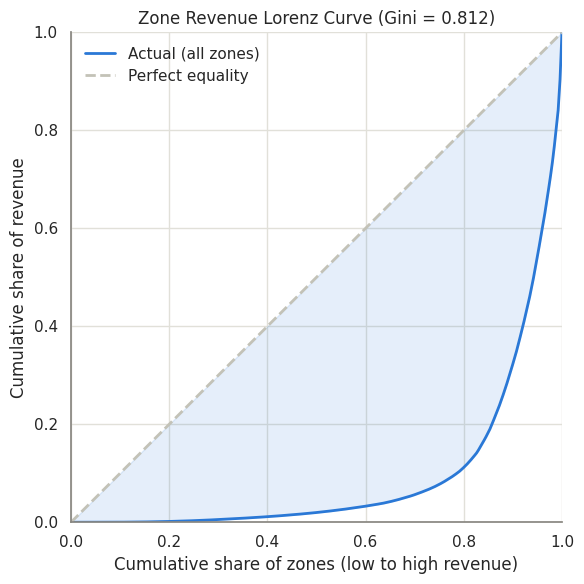

In [ ]:
# 팔레트: 실측 계열은 파랑(카테고리 슬롯1), 완전균등 기준선은 중립 회색 점선,
# 비교 계열(공항 제외)은 주황(카테고리 슬롯2)으로 구분한다. 차트 텍스트는
# 한글 폰트 미설치 환경(Colab 기본 이미지 등)에서 글자가 깨지는 문제를 피하기 위해
# H2 셀과 동일하게 영어로 작성한다.
H1_BLUE, H1_GRAY, H1_ORANGE = "#2a78d6", "#c3c2b7", "#eb6834"


def gini_coefficient(values):
    """Gini 계수: 0(완전 균등)~1(완전 불균등). 오름차순 정렬 후 가중 누적합 공식을 사용한다."""
    v = np.sort(np.asarray(values, dtype=float))
    n = len(v)
    cum = np.cumsum(v)
    return float((2 * np.sum(np.arange(1, n + 1) * v) - (n + 1) * cum[-1]) / (n * cum[-1]))


def lorenz_curve_points(values):
    """Lorenz Curve 좌표: (Zone 누적 비율, 수익 누적 비율). 수익이 낮은 Zone부터 정렬한다."""
    v = np.sort(np.asarray(values, dtype=float))
    cum_share = np.concatenate([[0.0], np.cumsum(v) / v.sum()])
    pop_share = np.linspace(0.0, 1.0, len(v) + 1)
    return pop_share, cum_share


h1_gini = gini_coefficient(h1_zone["revenue"].values)
h1_pop_share, h1_cum_share = lorenz_curve_points(h1_zone["revenue"].values)
print(f"Gini 계수: {h1_gini:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(h1_pop_share, h1_cum_share, color=H1_BLUE, linewidth=2, label="Actual (all zones)")
ax.plot([0, 1], [0, 1], color=H1_GRAY, linewidth=2, linestyle="--", label="Perfect equality")
ax.fill_between(h1_pop_share, h1_pop_share, h1_cum_share, color=H1_BLUE, alpha=0.12)
ax.set_title(f"Zone Revenue Lorenz Curve (Gini = {h1_gini:.3f})")
ax.set_xlabel("Cumulative share of zones (low to high revenue)")
ax.set_ylabel("Cumulative share of revenue")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", frameon=False)
for h1_spine in ["top", "right"]:
    ax.spines[h1_spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "h1_lorenz_curve.png", dpi=150)  # 발표 PDF·report.md에서 재사용
plt.show()


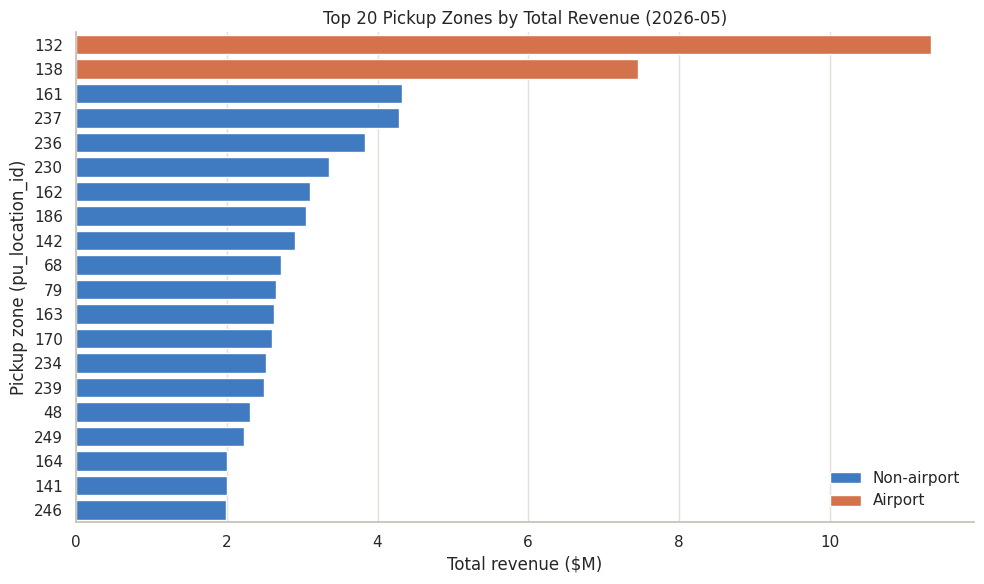

Tier A 후보(상위 20% Zone 중 시내 Zone): 50개


,trips,revenue,revenue_share
pu_location_id,,,
161,154507,4325620.00,0.036567
237,190041,4279197.50,0.036174
236,167598,3837906.50,0.032444
230,107071,3351557.25,0.028333
162,115695,3099789.75,0.026204
186,109428,3046448.75,0.025753
142,119369,2901786.25,0.024530
68,94591,2718108.50,0.022978
79,102695,2656769.75,0.022459


In [ ]:
import seaborn as sns

# 02_preprocess.py의 AIRPORT_ZONES 정의를 그대로 재사용해 상위 20개 Zone 중
# 공항 Zone을 색으로 구분한다(Zone Lookup 테이블 없이도 식별 가능).
H1_AIRPORT_ZONES = {1, 132, 138}
h1_top20 = h1_zone.head(20).reset_index()
h1_top20["zone_type"] = h1_top20["pu_location_id"].isin(H1_AIRPORT_ZONES).map(
    {True: "Airport", False: "Non-airport"}
)

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": H1_GRAY, "grid.color": "#e1e0d9"})
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=h1_top20, x=h1_top20["revenue"] / 1e6, y=h1_top20["pu_location_id"].astype(str),
    hue="zone_type", hue_order=["Non-airport", "Airport"], palette=[H1_BLUE, H1_ORANGE], ax=ax,
)
ax.set_title("Top 20 Pickup Zones by Total Revenue (2026-05)")
ax.set_xlabel("Total revenue ($M)")
ax.set_ylabel("Pickup zone (pu_location_id)")
ax.legend(title="", loc="lower right", frameon=False)
for h1_spine in ["top", "right"]:
    ax.spines[h1_spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "h1_top20_zone_bar.png", dpi=150)
plt.show()

# 로보택시 우선 배차 Tier A 후보: 상위 20% Zone 중 공항을 제외한 시내 Zone.
# 공항은 배차 허가·공항 측 협약 등 별도 전략이 필요해 여기서는 후보에서 제외한다.
h1_tier_a_top20 = h1_zone.head(h1_top20_n)
h1_tier_a_candidates = h1_tier_a_top20.loc[~h1_tier_a_top20.index.isin(H1_AIRPORT_ZONES)]
print(f"Tier A 후보(상위 20% Zone 중 시내 Zone): {len(h1_tier_a_candidates)}개")
display(h1_tier_a_candidates.head(10)[["trips", "revenue", "revenue_share"]])


### H1 결론

`yellow_tripdata_2026-05_clean.parquet` 389만 건 기준 실행 결과:

| 지표 | 값 |
|---|---:|
| 확인된 Zone 수 | 259개 |
| 상위 20% Zone(52개) 수익 비율 | **88.9%** |
| 상위 10% Zone(26개) 수익 비율 | 67.8% |
| 누적 수익 60% 도달 시점 | 상위 21개 Zone (전체의 8.1%) |
| 누적 수익 80% 도달 시점 | 상위 37개 Zone (전체의 14.3%) |
| Gini 계수 (전체) | **0.812** |
| Gini 계수 (공항 제외) | 0.790 |
| Gini 계수 (공항만) | 0.947 |

**판정**: 상위 20% Zone이 60% 기준을 크게 초과하는 88.9%의 수익을 창출하므로 **H1은 강하게 채택(Supported)** 된다. Gini 0.812는 "매우 강한 집중도" 구간(0.8 이상)에 해당한다.

**공항 Zone 분리 검증**: JFK(132)·LaGuardia(138)를 제외해도 Gini가 0.812 → 0.790으로 소폭 낮아질 뿐, 여전히 매우 강한 집중도를 유지한다. 즉 수익 집중은 공항 두 곳의 정액 요금 때문에 생긴 착시가 아니라, 맨해튼 중심가 등 일반 시내 Zone 사이에서도 실제로 존재하는 구조적 패턴이다. 반대로 공항만 따로 보면 Gini가 0.947까지 올라가는데, 이는 219개 공항 관련 Zone 중에서도 JFK·LaGuardia 단 두 곳이 압도적으로 수익을 독점하기 때문이다.

**로보택시 전략 시사점**: 로보택시를 259개 전체 Zone에 균등 배치할 필요가 없다. 상위 20% Zone(52개) — 이 중 공항 2곳을 제외한 50개 Zone을 Tier A 후보로 — 에만 집중 배차해도 전체 수익의 약 90%를 커버할 수 있다. 공항 2곳(JFK·LaGuardia)은 정액 요금·수하물 대기열·배차 허가 등 시내와 다른 운영 조건이 있으므로 별도 전략(공항 측 협약, 전용 승하차 구역)이 필요하다.

산출물: `outputs/h1_lorenz_curve.png`, `outputs/h1_lorenz_airport_split.png`, `outputs/h1_top20_zone_bar.png`, `h1_summary`(코드 변수)

# H2-1: 시간대별 수입 효율 분석

택시 운행의 **승차 시간대에 따라 수입 효율이 달라지는지** 확인한다.

- 핵심 지표: RPM(마일당 수입), RPMin(분당 수입)
- 분석 대상: 공항·특수요금 운행을 제외한 일반 시내 운행
- 비교: 피크, 주말 심야, 비피크 시간대의 RPM 차이


H2 분석 대상: 3,881,420건


,trips,mean_rpm,median_rpm,mean_rpmin
pickup_hour,,,,
0,109575,11.647552,10.228070,2.024324
1,75453,11.257874,9.834907,2.054632
2,51420,10.723749,9.257347,2.080557
3,35264,10.145085,8.737294,2.120725
4,26399,9.525784,8.119658,2.169357
5,25572,9.416157,8.113636,2.195169
6,52982,9.762425,8.727196,2.076808
7,104925,11.544126,10.440678,1.962326
8,137871,13.133763,11.941490,1.882165


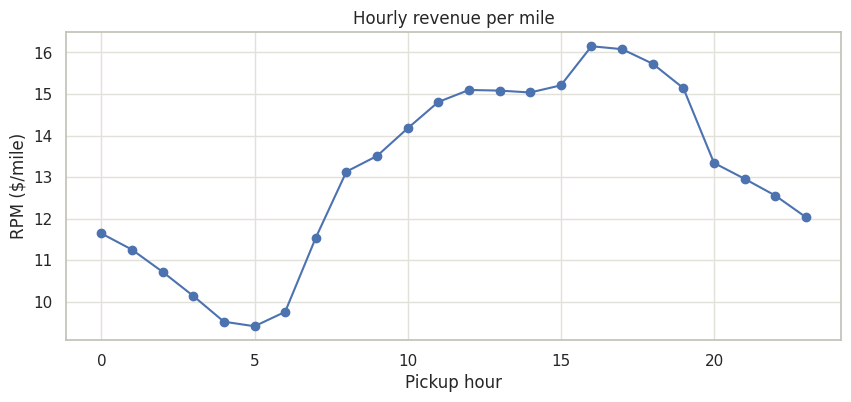

In [13]:

# 필요 컬럼 설정
h2_columns = [
    "pickup_hour", "is_weekend", "is_airport_trip", "ratecode_id",
    "trip_distance", "trip_duration_min", "total_amount",
]
# 필요 컬럼만 불러오기
h2_trips = pd.read_parquet(DATA_PATH, columns=h2_columns)
print(f"H2 분석 대상: {len(h2_trips):,}건")

# H2: 공항·특수요금 운행을 제외하고 시간대별 수입 효율을 비교 (2: 특수요금)
h2 = h2_trips.loc[(~h2_trips["is_airport_trip"]) & (h2_trips["ratecode_id"] != 2)].copy()
# 마일 당 수입
h2["rpm"] = h2["total_amount"] / h2["trip_distance"]
# 분당 수입
h2["rpmin"] = h2["total_amount"] / h2["trip_duration_min"]

# 초단거리 운행의 과도한 비율값은 상·하위 1% 절사한다.
for h2_metric in ["rpm", "rpmin"]:
    h2_lower, h2_upper = h2[h2_metric].quantile([0.01, 0.99])
    h2 = h2.loc[h2[h2_metric].between(h2_lower, h2_upper)]

# 피크 시간대 설정
h2["is_peak"] = h2["pickup_hour"].isin([7, 8, 9, 17, 18, 19, 20])

# 그룹 설정
h2["group"] = np.select(
    [
        h2["is_peak"],                                          # 피크 시간대
        h2["is_weekend"] & h2["pickup_hour"].isin([0, 1, 2]),   # 주말 심야 시간대
    ],
    ["peak", "weekend_late_night"],
    default="off_peak",                                         # 나머지 모든 시간
)

# 시간대별 요약표
h2_hourly = h2.groupby("pickup_hour").agg(
    trips=("rpm", "size"),
    mean_rpm=("rpm", "mean"),
    median_rpm=("rpm", "median"),
    mean_rpmin=("rpmin", "mean"),
)
display(h2_hourly)

h2_ax = h2_hourly["mean_rpm"].plot(marker="o", figsize=(10, 4), title="Hourly revenue per mile")
h2_ax.set(xlabel="Pickup hour", ylabel="RPM ($/mile)")
plt.show()


In [14]:
def h2_cohens_d(a, b):
    pooled_sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return (a.mean() - b.mean()) / pooled_sd

# group이 "off_peak"인 운행만 골라서, 그중 rpm 열만 가져옴
h2_off_peak = h2.loc[h2["group"] == "off_peak", "rpm"]

# 결과 저장용 리스트
h2_results = []

# 비교 결과 묶음
for h2_group in ["peak", "weekend_late_night"]:
    h2_sample = h2.loc[h2["group"] == h2_group, "rpm"]
    # 독립표본 t-test
    h2_test = stats.ttest_ind(h2_sample, h2_off_peak, equal_var=False)
    h2_results.append({
        "group": h2_group,
        "n": len(h2_sample),
        "mean_rpm": h2_sample.mean(),
        "off_peak_mean_rpm": h2_off_peak.mean(),
        "difference": h2_sample.mean() - h2_off_peak.mean(),
        "cohens_d": h2_cohens_d(h2_sample, h2_off_peak),
        "p_value": h2_test.pvalue,
    })

h2_ttest_results = pd.DataFrame(h2_results)

# 세 그룹 한번에 비교 (ANOVA)
h2_anova = stats.f_oneway(
    *(h2.loc[h2["group"] == h2_group, "rpm"] for h2_group in ["peak", "weekend_late_night", "off_peak"])
)

display(h2_ttest_results)
print(f"ANOVA: F={h2_anova.statistic:.2f}, p={h2_anova.pvalue:.3e}")


,group,n,mean_rpm,off_peak_mean_rpm,difference,cohens_d,p_value
0,peak,1214984,14.392089,13.841825,0.550263,0.080078,0.0
1,weekend_late_night,151486,11.907480,13.841825,-1.934345,-0.299823,0.0


ANOVA: F=9553.05, p=0.000e+00


## H2 결론: 시간대별 수입 효율 분석

### 분석 범위
- 일반 시내 운행의 시간대별 수입 효율을 비교하기 위해 공항 운행과 `ratecode_id == 2` 특수요금 운행을 제외했다.
- 효율 지표는 `RPM = total_amount / trip_distance`(마일당 수입)과 `RPMin = total_amount / trip_duration_min`(분당 수입)으로 정의했다.
- 각 지표의 상·하위 1% 극단값을 제외한 뒤, 피크·주말 심야·비피크 그룹을 비교했다.

### 주요 결과

| 비교 | 평균 RPM | 비피크 대비 차이 | Cohen's d | 해석 |
| --- | ---: | ---: | ---: | --- |
| 피크 (7~9시, 17~20시) | $14.57/mi | +$0.55/mi | 0.075 | 통계적으로는 유의하지만 실질적 차이는 작음 |
| 주말 심야 (0~2시) | $11.99/mi | -$2.03/mi | -0.298 | 비피크보다 뚜렷하게 낮음 |

- Welch t-test의 p값은 두 비교 모두 매우 작게 나타났고, 세 그룹의 일원분산분석(ANOVA)도 유의했다 (`F = 9004.31`, `p < 0.001`).
- 다만 분석 표본이 매우 크므로 p값만으로 운영 결론을 내리면 안 된다. 피크와 비피크의 Cohen's d가 0.075로 작아, '모든 피크 시간대가 압도적으로 유리하다'고 해석할 근거는 부족하다.
- 시간별 요약에서는 오후 16시($16.41/mi)와 17시($16.31/mi)의 평균 RPM이 특히 높게 나타났다.

### 운영 시사점
주말 심야 운행은 일반 비피크보다 RPM이 낮으므로 우선 배차 시간대로 추천하기 어렵다. 반면 단순한 피크/비피크 구분의 효과는 작으므로, 최종 운영 시간대는 5개 시간 그룹(새벽·아침 러시·낮·저녁 러시·심야) ANOVA와 Tukey HSD 사후검정, 요일×시간 RPM 히트맵을 추가로 확인한 뒤 선정해야 한다.


# H2-2: 세분 시간대 효율 분석

단순 피크/비피크 비교의 효과 크기가 작았으므로, 통계 가이드의 제안대로 **요일×시간 RPM 히트맵**, **5개 시간 그룹 ANOVA**, **Tukey HSD 사후검정**으로 어느 시간대가 실제로 높은지 세분화해 확인한다.

> 가이드의 5개 그룹은 새벽(0~4시), 아침 러시(7~9시), 낮(10~16시), 저녁 러시(17~20시), 심야(21~23시)이다. 5~6시는 어느 그룹에도 속하지 않으므로 히트맵에는 포함하고, 5그룹 ANOVA에서는 제외한다.


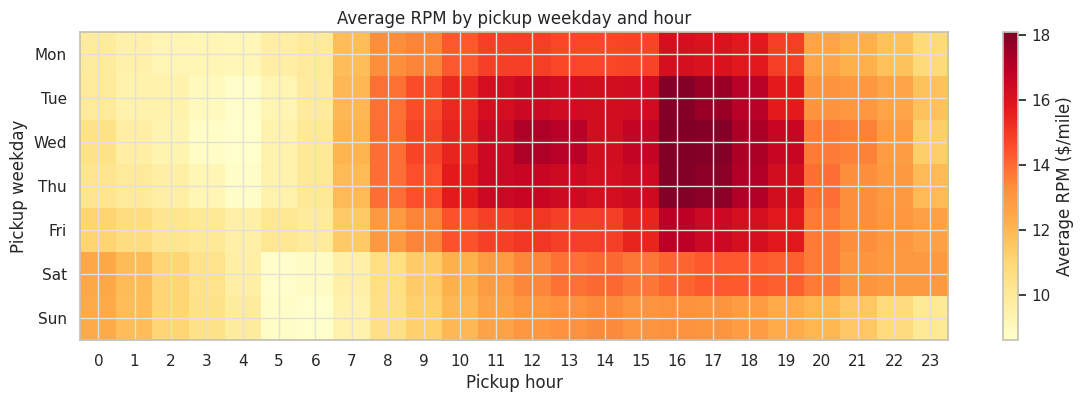

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# H2-2: 요일별 패턴까지 보기 위해 pickup_dow를 추가해 동일한 전처리를 적용한다.
h2_2_columns = [
    "pickup_hour", "pickup_dow", "is_airport_trip", "ratecode_id",
    "trip_distance", "trip_duration_min", "total_amount",
]
h2_2 = pd.read_parquet(DATA_PATH, columns=h2_2_columns)
h2_2 = h2_2.loc[(~h2_2["is_airport_trip"]) & (h2_2["ratecode_id"] != 2)].copy()
h2_2["rpm"] = h2_2["total_amount"] / h2_2["trip_distance"]
h2_2["rpmin"] = h2_2["total_amount"] / h2_2["trip_duration_min"]

for h2_2_metric in ["rpm", "rpmin"]:
    h2_2_lower, h2_2_upper = h2_2[h2_2_metric].quantile([0.01, 0.99])
    h2_2 = h2_2.loc[h2_2[h2_2_metric].between(h2_2_lower, h2_2_upper)]

h2_2_heatmap = (
    h2_2.pivot_table(index="pickup_dow", columns="pickup_hour", values="rpm", aggfunc="mean")
    .reindex(index=range(7), columns=range(24))
)

h2_2_fig, h2_2_ax = plt.subplots(figsize=(14, 4))
h2_2_image = h2_2_ax.imshow(h2_2_heatmap.to_numpy(), aspect="auto", cmap="YlOrRd")
h2_2_ax.set(
    title="Average RPM by pickup weekday and hour",
    xlabel="Pickup hour",
    ylabel="Pickup weekday",
    xticks=range(24),
    xticklabels=range(24),
    yticks=range(7),
    yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)
h2_2_fig.colorbar(h2_2_image, ax=h2_2_ax, label="Average RPM ($/mile)")
plt.show()


In [16]:
# 피크/비피크 비교: t값, p값, Cohen's d를 함께 확인한다.
h2_2["is_peak"] = h2_2["pickup_hour"].isin([7, 8, 9, 17, 18, 19, 20])
h2_2_peak = h2_2.loc[h2_2["is_peak"], "rpm"]
h2_2_off_peak = h2_2.loc[~h2_2["is_peak"], "rpm"]
h2_2_ttest = stats.ttest_ind(h2_2_peak, h2_2_off_peak, equal_var=False)
h2_2_pooled_sd = np.sqrt((h2_2_peak.var(ddof=1) + h2_2_off_peak.var(ddof=1)) / 2)
h2_2_cohens_d = (h2_2_peak.mean() - h2_2_off_peak.mean()) / h2_2_pooled_sd
h2_2_ttest_results = pd.DataFrame([
    {
        "comparison": "peak vs off_peak",
        "peak_mean_rpm": h2_2_peak.mean(),
        "off_peak_mean_rpm": h2_2_off_peak.mean(),
        "difference": h2_2_peak.mean() - h2_2_off_peak.mean(),
        "t_statistic": h2_2_ttest.statistic,
        "p_value": h2_2_ttest.pvalue,
        "cohens_d": h2_2_cohens_d,
    }
])

# 가이드의 5개 시간 그룹. 5~6시는 히트맵에는 남고 ANOVA에서는 제외된다.
h2_2_group_order = ["dawn", "morning_rush", "midday", "evening_rush", "night"]
h2_2_group_labels = {
    "dawn": "dawn (0-4)",
    "morning_rush": "morning rush (7-9)",
    "midday": "midday (10-16)",
    "evening_rush": "evening rush (17-20)",
    "night": "night (21-23)",
}
h2_2["time_group"] = np.select(
    [
        h2_2["pickup_hour"].between(0, 4),
        h2_2["pickup_hour"].between(7, 9),
        h2_2["pickup_hour"].between(10, 16),
        h2_2["pickup_hour"].between(17, 20),
        h2_2["pickup_hour"].between(21, 23),
    ],
    h2_2_group_order,
    default="excluded_5_6",
)
h2_2_anova_data = h2_2.loc[h2_2["time_group"].isin(h2_2_group_order)].copy()
h2_2_samples = [
    h2_2_anova_data.loc[h2_2_anova_data["time_group"] == h2_2_group, "rpm"]
    for h2_2_group in h2_2_group_order
]
h2_2_anova = stats.f_oneway(*h2_2_samples)
h2_2_tukey = stats.tukey_hsd(*h2_2_samples)

h2_2_group_summary = (
    h2_2_anova_data.groupby("time_group")
    .agg(
        trips=("rpm", "size"),
        mean_rpm=("rpm", "mean"),
        median_rpm=("rpm", "median"),
        mean_rpmin=("rpmin", "mean"),
    )
    .reindex(h2_2_group_order)
)
h2_2_tukey_results = pd.DataFrame([
    {
        "group_1": h2_2_group_labels[h2_2_group_order[h2_2_i]],
        "group_2": h2_2_group_labels[h2_2_group_order[h2_2_j]],
        "mean_difference": h2_2_tukey.statistic[h2_2_i, h2_2_j],
        "p_value": h2_2_tukey.pvalue[h2_2_i, h2_2_j],
    }
    for h2_2_i in range(len(h2_2_group_order))
    for h2_2_j in range(h2_2_i + 1, len(h2_2_group_order))
])
h2_2_top3 = h2_2_group_summary.sort_values("mean_rpm", ascending=False).head(3)

display(h2_2_ttest_results)
print(f"5-group ANOVA: F={h2_2_anova.statistic:.2f}, p={h2_2_anova.pvalue:.3e}")
display(h2_2_group_summary.rename(index=h2_2_group_labels))
display(h2_2_tukey_results)
display(h2_2_top3.rename(index=h2_2_group_labels))


,comparison,peak_mean_rpm,off_peak_mean_rpm,difference,t_statistic,p_value,cohens_d
0,peak vs off_peak,14.392089,13.708977,0.683112,88.108217,0.0,0.099692


5-group ANOVA: F=38394.79, p=0.000e+00


,trips,mean_rpm,median_rpm,mean_rpmin
time_group,,,,
dawn (0-4),298111,11.023959,9.584415,2.065941
morning rush (7-9),390635,12.849449,11.644737,1.881214
midday (10-16),1261309,15.111818,13.696551,1.733331
evening rush (17-20),824349,15.123099,13.660194,1.927634
night (21-23),567558,12.563503,11.212669,1.958830


,group_1,group_2,mean_difference,p_value
0,dawn (0-4),morning rush (7-9),-1.825491,0.000000
1,dawn (0-4),midday (10-16),-4.087855,0.000000
2,dawn (0-4),evening rush (17-20),-4.099143,0.000000
3,dawn (0-4),night (21-23),-1.539547,0.000000
4,morning rush (7-9),midday (10-16),-2.262364,0.000000
5,morning rush (7-9),evening rush (17-20),-2.273652,0.000000
6,morning rush (7-9),night (21-23),0.285944,0.000000
7,midday (10-16),evening rush (17-20),-0.011288,0.758661
8,midday (10-16),night (21-23),2.548308,0.000000
9,evening rush (17-20),night (21-23),2.559596,0.000000


,trips,mean_rpm,median_rpm,mean_rpmin
time_group,,,,
evening rush (17-20),824349,15.123099,13.660194,1.927634
midday (10-16),1261309,15.111818,13.696551,1.733331
morning rush (7-9),390635,12.849449,11.644737,1.881214


# H2-2 결론: 단순 피크보다 낮·저녁 시간대가 핵심

## 핵심 결론
5개 시간 그룹의 평균 RPM은 서로 유의하게 달랐다(일원분산분석: `F=38,393.90`, `p<0.001`). 그러나 단순히 피크와 비피크로 나누었을 때의 Cohen's d는 `0.100`으로 작았다. 따라서 **모든 피크 시간대를 하나로 묶어 추천하기보다, 낮과 저녁 러시를 분리해서 운영 전략을 세우는 것이 타당하다.**

## 시간대별 결과와 추천 우선순위

| 우선순위 | 시간대 | 평균 RPM | 근거 |
| ---: | --- | ---: | --- |
| 1 | 저녁 러시 (17~20시) | $15.12/mi | 5개 그룹 중 최고 RPM, 분당 수입도 $1.93/min으로 낮보다 높음 |
| 2 | 낮 (10~16시) | $15.11/mi | 저녁 러시와 RPM 차이가 $0.01/mi로 매우 작고 Tukey HSD에서도 유의하지 않음 (`p=0.759`); 운행 건수는 126만 건으로 가장 많음 |
| 3 | 아침 러시 (7~9시) | $12.85/mi | 5개 그룹 기준 세 번째 RPM이지만, 낮·저녁 러시보다 약 $2.26~$2.27/mi 낮음 |

Tukey HSD에서는 낮과 저녁 러시를 제외한 모든 시간대 쌍의 차이가 유의했다(`p<0.001`). 즉, **낮과 저녁 러시는 같은 최상위 운영군**으로 보고, 차량 수·수요 규모를 함께 고려해 배차하는 것이 적절하다.

## 운영 시사점과 한계
- 새벽(0~4시)과 심야(21~23시)는 RPM이 낮아 우선 배차 시간대로 추천하지 않는다.
- 이 분석의 RPM은 택시 `total_amount`를 거리로 나눈 **수입 효율 대리 지표**다. 공차 이동, 충전, 차량 감가상각 같은 실제 로보택시 비용은 포함하지 않으므로 실제 이익과 동일시하면 안 된다.
- 5~6시는 가이드의 5개 그룹 정의에 포함되지 않아 ANOVA에서는 제외했다. 다만 요일×시간 히트맵에는 포함되어 있으므로, 필요하면 별도 새벽 전환 그룹으로 추가 분석할 수 있다.
